<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/AstroEstadistica/PARCIAL1_ESTADISTIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random

# **Experimento de las 3 bolas equiprobables en una bolsa**

### **Punto 4 computacional. suponga que se tiene 3 bolas de 3 colores (azul, verde, roja) metidas en una bolsa negra. cuál es la probabilidad de extraer una bola roja después de haber extraído una bola azul?**
<br>

Primero, analizando el caso $1$; sacar la primer bola y que sea de un color particular, tomando la interpretación objetiva frecuentista; se tienen eventos simples disyuntos $A_i$={sacar una bola de un color $S_A$=($1$:azul, $2$:rojo, $3$:verde)}; con $i ∈ \{1,2,3\}$, es decir $A_1$={sacar azul}. Además, como las $3$ bolas están dentro de una bolsa negra, no hay ninguna preferencia al elegir un color sobre otro, de modo que se trata de eventos equiprobables. Luego la probabilidad teórica se puede ver como los casos favorables sobre los totales, de modo que se puede afirmar que cada una de las $3$ bolas tiene una probabilidad de salir de $P(A_i)=1/3$ <br>

Ahora, analizando el caso $2$; después de sacar la primer bola (azul), la bolsa queda con 2 bolas restantes (roja y verde), en este punto, sea el evento $B_j=${sacar una bola de otro color ($2$:rojo, $3$:verde)}; con $j ∈ \{2,3\}$. Con un análisis análogo al caso anterior, se tendría que la probabilidad de $B_2$ condicionado a $A_1$, es decir; de obtener la bola roja después de haber sacado la azul, es $P(B_j|A_1)=1/2$, pues como se sacó la azul previamente, en la bolsa quedan $2$ bolas (roja y verde) que nuevamente son equiprobables. <br>

Por otra parte, para tomando el experimento conjunto estrictamente de $A_1$ intersecado $B_1$, es decir; de sacar la azul **y** luego la roja, se puede utilizar la fórmula de probabilidad condicional, debido a que $B_1$ está condicionado a $A_1$, donde se obtiene:

$$ P(B_2|A_1) = P(B_2 \wedge A_1) / P(A_1) $$
$$ P(B_2 \wedge A_1) = P(B_2|A_1) * P(A_1) $$
$$ P(B_2 \wedge A_1) = \frac{1}{2}*\frac{1}{3} = \frac{1}{6}$$





#### 1. **simulacion del proceso de sacar una bola de la bolsa, para N=[10,100,1000,10000]**

Se definió una función que dado el número de repeticiones $N$ y el color deseado, junto con el uso de la función “random.choice” en Python, y un contador que incrementaba por cada éxito(cada vez que salía el color deseado de una lista que contenía los $3$ colores), entregaba la frecuencia relativa $N(A)/N$ asociada a cada $N$, donde $N(A)$ es el número de veces que se dio el éxito. De donde se obtuvo:



In [ ]:
bolas = ['blue','red','green']
col = ['azul','rojo','verde']

def sacar_una(n, color):
  i=0; numero_exitos = 0

  for i in range(n):
    if random.choice(bolas) == color: # primer sacada
      numero_exitos += 1

  return numero_exitos

Color: blue
  N repeticiones: [    10    100   1000  10000 100000]
  exitos: [    2    37   312  3252 33347]
  frec: [0.2     0.37    0.312   0.3252  0.33347]

Color: red
  N repeticiones: [    10    100   1000  10000 100000]
  exitos: [    5    39   351  3327 33511]
  frec: [0.5     0.39    0.351   0.3327  0.33511]

Color: green
  N repeticiones: [    10    100   1000  10000 100000]
  exitos: [    5    34   315  3321 33243]
  frec: [0.5     0.34    0.315   0.3321  0.33243]



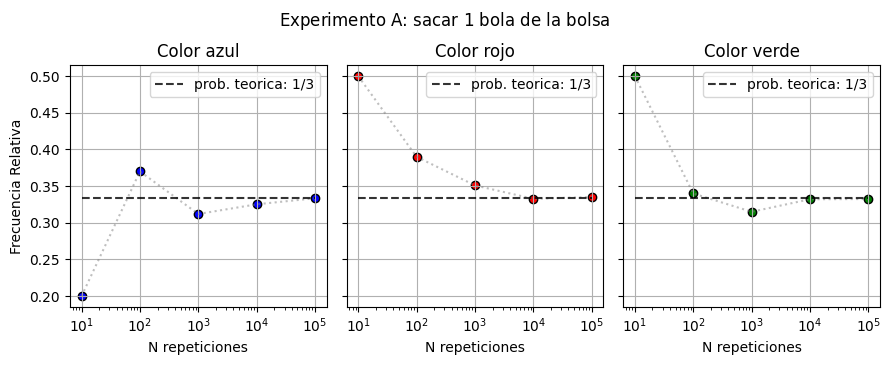

In [ ]:
teorica = 1/3 # para sacar 1 bola

fig, ax = plt.subplots(1,3, figsize=(9,4), sharey=True)
fig.suptitle(f'Experimento A: sacar $1$ bola de la bolsa\n', y=0.9)
ax[0].set_ylabel('Frecuencia Relativa')

for i,color_i in enumerate(bolas):

  Ns = np.array( [10**j for j in range(1,6)] ) # N repeticiones
  exitos = np.array( [sacar_una(Nj, color_i) for Nj in Ns] )
  frec = exitos/Ns

  print(f'Color: {color_i}')
  print(f'  N repeticiones: {Ns}')
  print(f'  exitos: {exitos}')
  print(f'  frec: {frec}\n')

  ax[i].set_title(f'Color {col[i]}')
  ax[i].plot(Ns, frec, ':', color='gray', alpha=0.5) # liniesitas
  ax[i].scatter(Ns, frec, marker='o', color=color_i, edgecolor='k') # puntos
  ax[i].hlines(teorica, Ns[0], Ns[-1], color='k', linestyle='--', alpha=0.8, label='prob. teorica: 1/3') # teorica
  ax[i].set_xlabel('N repeticiones')
  ax[i].set_xscale('log')
  ax[i].legend()
  ax[i].grid()

plt.tight_layout()
plt.show()

Figura 1. Estimación de la probabilidad de sacar una bola de cada color de la bolsa de 3.<br><br>

Similar al caso del experimento del lanzamiento del dado, la frecuencia relativa en el limite cuando N se hace muy grande, tiende a converger a un valor especifico, en este caso también podemos observar tal tendencia a converger a un valor particular, que es el teórico de $1/3 = 0.\overline{3}$

De este modo, se puede hacer la estimación de la probabilidad de obtener cada bola tomando la frecuencia relativa obtenida con el mayor numero de repeticiones $N=10^{5}$, donde se obtuvo que la estimación:
* $P(\text{azul})  \approx 0.3335 $
* $P(\text{rojo})  \approx 0.3351 $
* $P(\text{verde}) \approx 0.3324 $

No obstante es importante recalcar que esta es una aproximación, pues la probabilidad como tal requiere el limite $N\rightarrow \infty $




#### **2. simulación del proceso intersecado: sacar primero azul y luego roja**

Ahora la función se modificó para que el contador diera éxito cuando se daba primero la extracción de la bola azul y de las dos que quedaban en la bolsa, se sacaba la roja. esta vez entonces el contador está condicionado, por lo que se puede esperar que la probabilidad de esta intersección sea menor que la individual de sacar la bola azul.



In [ ]:
def sacar_compuesto(n, color1, color2):
  i=0; numero_exitos=0

  for i in range(n):
    if random.choice(bolas) == color1: # primer sacada
      bolas.remove( color1 )           # quita la sacada

      if random.choice(bolas) == color2: # segunda sacada
        numero_exitos += 1

      bolas.append( color1 )           # vuelve a meterla

  return numero_exitos

Color: 
  N repeticiones: [    10    100   1000  10000 100000]
  exitos: [    2    20   148  1652 16622]
  frec: [0.2     0.2     0.148   0.1652  0.16622]



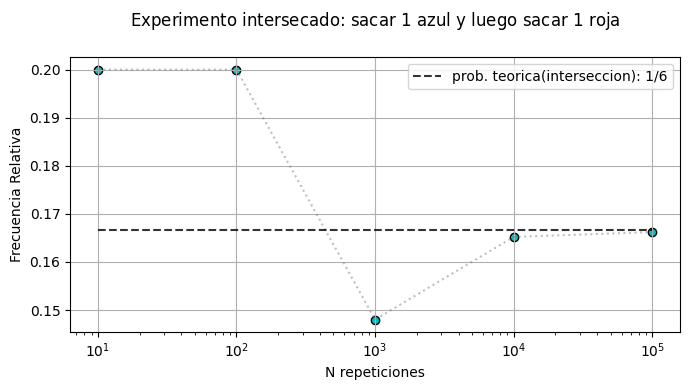

In [ ]:
teorica = 1/6 # para sacar 1 bola

fig, ax = plt.subplots(1,1, figsize=(7,4), sharey=True)
# fig.suptitle(f'Experimento compuesto: sacar $1$ azul y luego sacar 1 roja\n', y=0.9)
ax.set_ylabel('Frecuencia Relativa')

Ns = np.array( [10**j for j in range(1,6)] ) # N repeticiones
exitos = np.array( [sacar_compuesto(Nj, 'blue', 'red') for Nj in Ns] )
frec = exitos/Ns

print(f'Color: ')
print(f'  N repeticiones: {Ns}')
print(f'  exitos: {exitos}')
print(f'  frec: {frec}\n')

ax.set_title(f'Experimento intersecado: sacar $1$ azul y luego sacar 1 roja\n')
ax.plot(Ns, frec, ':', color='gray', alpha=0.5) # liniesitas
ax.scatter(Ns, frec, marker='o', color='c', edgecolor='k') # puntos
ax.hlines(teorica, Ns[0], Ns[-1], color='k', linestyle='--', alpha=0.8, label='prob. teorica(interseccion): 1/6') # teorica
ax.set_xlabel('N repeticiones')
ax.set_xscale('log')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

Figura 2. Estimación de la probabilidad de sacar la bola azul de la bolsa, y luego de las 2 bolas restantes sacar la roja.<br><br>

Similarmente al punto anterior, a medida que el número de repeticiones aumenta, la frecuencia relativa se aproxima más al valor teórico encontrado para la intersección, que es $P(B_2 \wedge A_1)=1/6 = 0.1\overline{6}$. Empleando el mismo criterio del punto previo, la estimación para la intersección se realizó asociada al número mayor de repeticiones, donde se encontró numéricamente que:

* $P(\text{azul y luego roja})  \approx 0.1662 $

Por otro lado, usando este valor estimado junto al del punto anterior, también se puede estimar la condicionada; que luego de haber sacado la bola azul, la probabilidad de obtener la roja, es, usando la probabilidad condicional:

* $P(\text{roja}|\text{azul}) = \frac{P(\text{azul y luego roja})}{P(\text{azul})} \approx \frac{0.16622}{0.3335} \approx 0.4984 $

Recordando que el valor teórico es $P(B_2|A_1)=1/2$, esta última aproximación es relativamente buena.



#### **3. identifique el proceso complementario, se puede interpretar el proceso complementario al anterior? cual es la probabilidad de este?**

El proceso complementario es la negación del anterior, es decir los casos opuestos a que se dé la intersección, que son: obtener la roja o la verde en el primer caso, o obtener primero la azul y después la verde (no roja), entonces hay 3 casos por los cuales el contador aumenta, a diferencia del caso anterior, donde el contador marcaba éxito con solo 1 evento. De modo que es esperable que esta probabilidad complementaria sea mayor que la del punto previo.

Como es el complemento, su probabilidad teóricamente es:
$$ P( (A_1 \wedge B_2)' )=1-P(A_1 \wedge B_2) = 1-1/6 = 0.8\overline{3} $$










In [ ]:
def compuesto_complementario(n, color1, color2):
  c3 = bolas.copy()
  c3.remove(color1); c3.remove(color2)
  color3 = c3[0]

  i=0; numero_exitos=0

  for i in range(n):
    eleccion_1 = random.choice(bolas)

    if eleccion_1 == color2 or eleccion_1 == color3: # primer sacada (2 casos de interes)
      numero_exitos += 1

    if eleccion_1 == color1: # primer sacada
      bolas.remove( color1 ) # quita la sacada

      if random.choice(bolas) == color3: # segunda sacada
        numero_exitos += 1

      bolas.append( color1 ) # vuelve a meterla

  return numero_exitos

Color: 
  N repeticiones: [    10    100   1000  10000 100000]
  exitos: [    6    75   848  8315 83294]
  frec: [0.6     0.75    0.848   0.8315  0.83294]



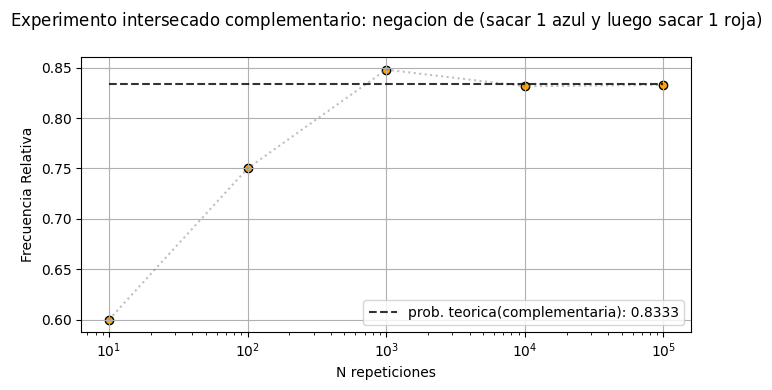

In [ ]:
teorica_comp = 1-1/6 # para sacar 1 bola

fig, ax = plt.subplots(1,1, figsize=(7,4), sharey=True)
ax.set_ylabel('Frecuencia Relativa')

Ns = np.array( [10**j for j in range(1,6)] ) # N repeticiones
exitos = np.array( [compuesto_complementario(Nj, 'blue', 'red') for Nj in Ns] )
frec = exitos/Ns

print(f'Color: ')
print(f'  N repeticiones: {Ns}')
print(f'  exitos: {exitos}')
print(f'  frec: {frec}\n')

ax.set_title(f'Experimento intersecado complementario: negacion de (sacar $1$ azul y luego sacar 1 roja)\n')
ax.plot(Ns, frec, ':', color='gray', alpha=0.5) # liniesitas
ax.scatter(Ns, frec, marker='o', color='orange', edgecolor='k') # puntos
ax.hlines(teorica_comp, Ns[0], Ns[-1], color='k', linestyle='--', alpha=0.8, label='prob. teorica(complementaria): 0.8333') # teorica
ax.set_xlabel('N repeticiones')
ax.set_xscale('log')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

Figura 3. Estimación de la probabilidad complementaria de sacar la bola azul de la bolsa, y luego de las 2 bolas restantes sacar la roja.<br><br>

Observada la tendencia de convergencia al valor teórico, la estimación de la probabilidad complementaria a la intersección, asociada al mayor número de iteraciones en este caso fue de $ P( (A_1 \wedge B_2)' ) ≈ 0.8329 $



#### 4. **Comparación los resultados numéricos con la teoría**

En general se puede concluir que las aproximaciones numéricas realizadas, cuando el número de iteraciones $N$ es muy grande, se ajustan bien a los modelos teóricos empleados, que fueron la interpretación de la probabilidad objetiva frecuentista, los eventos equiprobables, y probabilidad condicional. A pesar de que como es evidente, los valores encontrados numéricamente fallan en algunos decimales, pues no hay que olvidar que los valores se ajustarían aún mejor a la teoría para un $N$ tendiendo a infinito, cosa no posible computacionalmente. Así pues, a manera de primera aproximación, los valores encontrados concuerdan en buena medida con los esperados.
